810597

# Tarefa 4 - Random Forest com valores ausentes e K-means

Quarta tarefa avaliada da disciplina **Técnicas e Algoritmos em Ciência de Dados**.

Esta versão tem duas partes:

1. [Random Forest com valores ausentes](#Classification) (60%)
2. [Agrupamento com K-means](#K-Means) (40%)

Use o mesmo identificador aleatório de 6 dígitos usado nas tarefas anteriores e escreva-o na primeira célula do seu notebook submetido.

Você pode usar `numpy`, `pandas`, `matplotlib` e métricas de avaliação como AUROC. Você **não pode** usar implementações prontas de árvore de decisão, Random Forest, K-means ou ferramentas prontas de busca automática de parâmetros. Qualquer função auxiliar deve estar dentro deste notebook.


In [2]:
import math

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    PLOTTING_AVAILABLE = True
except ModuleNotFoundError:
    plt = None
    PLOTTING_AVAILABLE = False
    print("matplotlib não está instalado neste ambiente; ele será necessário para gerar os gráficos pedidos.")

try:
    display
except NameError:
    def display(obj):
        print(obj)


def roc_auc_score(y_true, y_score):
    """Calcula AUROC para rótulos binários, com tratamento correto de empates."""
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    positive = y_true == 1
    negative = y_true == 0
    n_pos = int(positive.sum())
    n_neg = int(negative.sum())
    if n_pos == 0 or n_neg == 0:
        raise ValueError("AUROC requer exemplos das duas classes.")

    order = np.argsort(y_score, kind="mergesort")
    sorted_scores = y_score[order]
    ranks = np.empty(len(y_score), dtype=float)
    start = 0
    while start < len(y_score):
        end = start + 1
        while end < len(y_score) and sorted_scores[end] == sorted_scores[start]:
            end += 1
        average_rank = (start + 1 + end) / 2.0
        ranks[order[start:end]] = average_rank
        start = end

    rank_sum_pos = ranks[positive].sum()
    return float((rank_sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))


<a id="Classification"></a>
## Parte 1 - Random Forest com valores ausentes (valor: 60%)

Você usará o arquivo `horse_colic_missing.csv`, baseado no conjunto Horse Colic. O alvo é `surgical_lesion`, em que `1` indica que o caso tinha lesão cirúrgica e `0` indica que não tinha.

Use apenas os atributos clínicos pré-desfecho listados abaixo. Não use `surgery`, `hospital_number`, `outcome`, códigos de lesão, `cp_data` ou outros campos que funcionem como identificadores, tratamento, desfecho ou vazamento de informação.

### Objetivo

Você pode reutilizar e adaptar suas implementações anteriores de árvore de decisão e Random Forest. O foco desta tarefa é modificar as árvores da floresta para lidar com valores ausentes durante a escolha das divisões, durante o treinamento e durante a predição.

### Estratégias obrigatórias para valores ausentes

Compare Florestas Aleatórias que diferem principalmente na forma como suas árvores tratam valores ausentes:

1. **Baseline simples de pré-processamento**: implemente uma referência simples, como imputação por mediana/moda aprendida apenas no treino. Essa estratégia serve como baseline.
2. **Roteamento fracionário por frequência de ramo**: ao avaliar uma divisão em um nó, use apenas os exemplos com valor observado naquele atributo para estimar as probabilidades dos ramos:

   ```text
   p_left = n_left_observed / n_observed
   p_right = n_right_observed / n_observed
   ```

   Os exemplos com valor ausente devem ser enviados para os dois filhos com esses pesos. A entropia, o ganho de informação e a frequência das classes nas folhas devem usar pesos: sempre que uma fórmula envolver contagem de exemplos, substitua a contagem pela soma dos pesos.

### O que entregar nesta parte

1. Carregue o conjunto de dados e descreva a fração de valores ausentes em cada atributo.
2. Faça a divisão treino/validação/teste com proporção 70/15/15 e `seed = 13`.
3. Adapte a árvore de decisão para usar pesos de amostras em entropia, ganho de informação e probabilidade da classe positiva nas folhas.
4. Armazene em cada nó interno as probabilidades de ramo estimadas a partir dos exemplos observados.
5. Implemente a predição para exemplos com valores ausentes usando o roteamento fracionário por frequência de ramo.
6. Implemente a Random Forest com bootstrap, subconjunto aleatório de atributos e agregação por média das probabilidades positivas ou média dos votos binários.
7. Escolha manualmente poucas combinações de hiperparâmetros usando AUROC na validação. Use `num_trees` entre 5 e 20 e profundidade máxima não superior a 5.
8. Treine novamente com treino + validação usando a melhor combinação de parâmetros e reporte acurácia com limiar 0.5 e AUROC no teste.
9. Compare as duas estratégias em uma tabela final e discuta qual funcionou melhor.


In [3]:
SEED = 13
TARGET = "surgical_lesion"
FEATURE_COLUMNS = [
    "age",
    "rectal_temperature",
    "pulse",
    "respiratory_rate",
    "temperature_of_extremities",
    "peripheral_pulse",
    "mucous_membranes",
    "capillary_refill_time",
    "pain",
    "peristalsis",
    "abdominal_distension",
    "nasogastric_tube",
    "nasogastric_reflux",
    "nasogastric_reflux_ph",
    "rectal_exam_feces",
    "abdomen",
    "packed_cell_volume",
    "total_protein",
    "abdominocentesis_appearance",
    "abdomcentesis_total_protein",
]

NUMERIC_COLUMNS = [
    "rectal_temperature",
    "pulse",
    "respiratory_rate",
    "nasogastric_reflux_ph",
    "packed_cell_volume",
    "total_protein",
    "abdomcentesis_total_protein",
]
CATEGORICAL_COLUMNS = [col for col in FEATURE_COLUMNS if col not in NUMERIC_COLUMNS]


df = pd.read_csv("horse_colic_missing.csv")
display(df.head())
missing_summary = df[FEATURE_COLUMNS].isna().mean().sort_values(ascending=False).rename("missing_fraction").to_frame()
display(missing_summary)


,source_split,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,pain,...,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdominocentesis_appearance,abdomcentesis_total_protein,surgical_lesion
0,uci_train_file,1,38.5,66.0,28.0,3.0,3.0,NaN,2.0,5.0,...,NaN,NaN,NaN,3.0,5.0,45.0,8.4,NaN,NaN,0
1,uci_train_file,1,39.2,88.0,20.0,NaN,NaN,4.0,1.0,3.0,...,NaN,NaN,NaN,4.0,2.0,50.0,85.0,2.0,2.0,0
2,uci_train_file,1,38.3,40.0,24.0,1.0,1.0,3.0,1.0,3.0,...,NaN,NaN,NaN,1.0,1.0,33.0,6.7,NaN,NaN,0
3,uci_train_file,9,39.1,164.0,84.0,4.0,1.0,6.0,2.0,2.0,...,1.0,2.0,5.0,3.0,NaN,48.0,7.2,3.0,5.3,1
4,uci_train_file,1,37.3,104.0,35.0,NaN,NaN,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,74.0,7.4,NaN,NaN,0


,missing_fraction
nasogastric_reflux_ph,0.812500
abdomcentesis_total_protein,0.638587
abdominocentesis_appearance,0.527174
abdomen,0.388587
nasogastric_reflux,0.361413
nasogastric_tube,0.355978
rectal_exam_feces,0.347826
peripheral_pulse,0.225543
respiratory_rate,0.192935
rectal_temperature,0.187500


In [4]:
def stratified_split(df, target=TARGET, train_size=0.70, val_size=0.15, seed=SEED):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    for _, group in df.groupby(target):
        idx = group.index.to_numpy().copy() # NOTE: criei uma copia, pois o original não pode ser modificado
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(round(train_size * n))
        n_val = int(round(val_size * n))
        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])
    return (
        df.loc[train_idx].sample(frac=1, random_state=seed).reset_index(drop=True),
        df.loc[val_idx].sample(frac=1, random_state=seed + 1).reset_index(drop=True),
        df.loc[test_idx].sample(frac=1, random_state=seed + 2).reset_index(drop=True),
    )


In [5]:
train_df, val_df, test_df = stratified_split(df)

X_train = train_df.drop(columns=["source_split", "surgical_lesion"]).values
X_val = val_df.drop(columns=["source_split", "surgical_lesion"]).values
X_test = test_df.drop(columns=["source_split", "surgical_lesion"]).values

y_train = train_df[TARGET].to_numpy(dtype=int)
y_val = val_df[TARGET].to_numpy(dtype=int)
y_test = test_df[TARGET].to_numpy(dtype=int)

print("Tamanhos treino/validação/teste:", len(train_df), len(val_df), len(test_df))
print("Distribuição do alvo no treino:", train_df[TARGET].value_counts(normalize=True).sort_index().to_dict())

# TODO: Necessario dropar "source_split" e "surgical_lesion"
#       do conjunto de treino, as demais  features  parecem 
#       corretas.

Tamanhos treino/validação/teste: 257 55 56
Distribuição do alvo no treino: {0: 0.36964980544747084, 1: 0.6303501945525292}


### Árvore de decisão ponderada

Implemente abaixo a adaptação da árvore de decisão. Sua implementação deve incluir:

- entropia ponderada;
- ganho de informação ponderado;
- probabilidade positiva ponderada em cada folha;
- escolha de divisões ignorando valores ausentes apenas para calcular as frequências observadas dos ramos;
- envio fracionário dos exemplos ausentes para os dois filhos;
- armazenamento de `p_left` e `p_right` em cada nó interno para uso na predição.


In [39]:
# Escreva aqui a implementação da árvore de decisão ponderada e do
# roteamento fracionário por frequência de ramo.
from collections import defaultdict


class Node:
    def __init__(self, feature, tau, p_left = 1, p_right = 1):
        self.feature = feature
        self.tau = tau
        self.p_left = p_left
        self.p_right = p_right

        self.left = None
        self.right = None

class Leaf:
    def __init__(self, value, proportions):
        self.value = value
        self.proportions = proportions

class Tree:
    def __init__(self):
        self.root = None

    # é o que queremos minimizar
    # representa de certa forma a variança, se muitos targets da região
    # são da mesma categoria então a entropia sera baixa.
    # NOTE: FEITO
    def entropy(self, labels_region: np.ndarray, weights: np.ndarray) -> float:
        """Calcula a entropia de uma "Região"

        Para os targets de uma região calcula a entropia com a seguinte formula:

            -(p * log_{2}(p) +  (1 - p) * log_{2}(1 - p))

        onde p representa a proporção de peso da classe positiva.
        
        Args:
            labels_region (np.ndarray): array contendo as categorias de cada instancia, ele é (N, )
                                 a i-esima entrada indica a qual categoria perctence a i-esima
                                 instancia de dados.

            weights (np.ndarray): array condendo os pesos de cada instancia para o calculo da entropia.
        Returns:
            float: entropia
        """ 
        
        weight_classes = np.bincount(labels_region, weights, 2)
        weight_region = np.sum(weight_classes)

        if weight_region == 0:
            return 0.0

        p = weight_classes[1] / weight_region

        # usamos uma tolerancia pois os pesso são floats
        if np.isclose(p, 0.0) or np.isclose(p, 1.0):
            return 0.0

        return -(p * np.log2(p) + (1-p) * np.log2(1-p))

    # é o que queremos maximixar
    # NOTE: FEITO
    def gain(
            self,
            parent_entropy: float,
            parent_weight: float,
            labels_left: np.ndarray,
            labels_right:np.ndarray,
            left_w: np.ndarray,
            right_w:np.ndarray
    ) -> float:

        WL = np.sum(left_w)
        WR = np.sum(right_w)

        EL = self.entropy(labels_left, left_w)
        ER = self.entropy(labels_right, right_w)

        gain = parent_entropy - (WL / parent_weight)*EL - (WR / parent_weight)*ER

        return gain
    
    # NOTE: FEITO
    def split_region(self, region: np.ndarray, idfeature: int, tau:float):
        col = region[:, idfeature]

        # Seleccionamos as linhas não nulas
        region_valid = ~np.isnan(col)
        region_invalid = ~region_valid

        # dividimos pelo tau
        left_valid_region = region_valid & (col < tau)
        right_valid_region = region_valid & (col >= tau)

        # adicionamos os NaN nas duas regioes
        left_region = left_valid_region | region_invalid
        right_region = right_valid_region | region_invalid

        N_left = np.sum(left_valid_region)
        N_right = np.sum(right_valid_region)

        total = N_left + N_right

        if total == 0:
            return left_region, right_region, region_invalid, 0.5, 0.5

        # calculamos a probabilidade (o peso)
        left_p = N_left / (total)
        right_p = N_right / (total)

        return left_region, right_region, region_invalid, left_p, right_p
    
    # NOTE: FEITO
    def get_split(self, X: np.ndarray, y:np.ndarray, w: np.ndarray) -> Node | Leaf:
        best_gain = 0.0

        best_tau = None
        best_feature = None

        n_samples, n_features = X.shape

        # para ser utilizado no calculo do gain
        parent_entropy = self.entropy(y, w)
        parent_weight = np.sum(w)

        # devemos ir por todas as features
        for each_feature in range(n_features):
            col = X[:, each_feature]
            valid_mask = ~np.isnan(col)

            # Queremos apenas os taus validos
            X_valid = X[valid_mask]
            order = X_valid[:, each_feature].argsort()

            # Acho o tau depois de achar o tau eu posso achar os indices das regioes
            X_sorted = X_valid[order]

            for i in range(1, X_sorted.shape[0]):

                v1 = X_sorted[i - 1, each_feature]
                v2 = X_sorted[i, each_feature]
                
                # evitar splits impossiveis
                if v1 == v2:
                    continue

                tau = (v1 + v2) / 2
                
                left_region, right_region, region_invalid, left_p, right_p = self.split_region(
                    X, each_feature, tau
                )

                w_left = w[left_region].copy()
                w_right = w[right_region].copy()

                # So os NaN recebem pesso fracionario
                w_left[region_invalid[left_region]] *= left_p
                w_right[region_invalid[right_region]] *= right_p
                
                gain = self.gain(
                    parent_entropy,
                    parent_weight,
                    y[left_region],
                    y[right_region],
                    w_left,
                    w_right
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feature = each_feature
                    best_tau = tau

        if best_feature is None:
            value = 1 if np.average(y, weights=w) > 0.5 else 0
            return Leaf(value)

        left_region, right_region, region_invalid, p_left, p_right =  self.split_region(
            X, best_feature, best_tau
        )

        left_w = w[left_region].copy()
        right_w = w[right_region].copy()

        # So os NaN recebem pesso fracionario
        left_w[region_invalid[left_region]] *= p_left
        right_w[region_invalid[right_region]] *= p_right

        node = Node(
            best_feature,
            best_tau,
            p_left,
            p_right,
        )

        return node, left_region, right_region, left_w, right_w
    
    
    def mode(self, y: np.ndarray, w: np.ndarray = None):

        # indice cero peso da classe 0, indice 1 pesso da classe 1
        weighted_counts = np.bincount(y, weights=w)

        return weighted_counts.argmax()


    def recursive_growth(self, min_samples, max_depth, current_depth, X, y, w):

        is_leaf = len(y) < min_samples or current_depth >= max_depth or np.isclose(self.entropy(y, w), 0.0)

        if is_leaf:
            majority_class = self.mode(y, w)

            #Calcula a proporção (probabilidade) de cada classe nesta folha
            proportions = defaultdict(float)
            total_weight = np.sum(w)
            
            for cls, weight in zip(y, w):
                proportions[cls] += weight / total_weight
                
            # Retorna a folha guardando ambas as informações
            return Leaf(value=majority_class, proportions=proportions)
    
        split_result = self.get_split(X, y, w)

        if isinstance(split_result, Leaf):
            return split_result
        
        node, left_region, right_region, left_w, right_w = split_result

        node.left = self.recursive_growth(
            min_samples, max_depth, current_depth + 1,
            X[left_region],
            y[left_region],
            left_w
        )

        node.right = self.recursive_growth(
            min_samples, max_depth, current_depth + 1,
            X[right_region],
            y[right_region],
            right_w
        )

        return node
    
    def predict_sample_multiverse(self, node: Node, sample: np.ndarray, w = 1, predicts:defaultdict = None):

        if predicts is None:
            predicts = defaultdict(float)

        is_leaf = isinstance(node, Leaf)
        if is_leaf:
            for cls, prob in node.proportions.items():
                predicts[cls] += w * prob
            return

        nan = np.isnan(sample[node.feature]).astype(bool)

        if not nan:
            if sample[node.feature] < node.tau:
                self.predict_sample_multiverse(node.left, sample, w, predicts)
            else: 
                self.predict_sample_multiverse(node.right, sample, w, predicts)
        else:
            self.predict_sample_multiverse(node.left, sample, w * node.p_left, predicts)
            self.predict_sample_multiverse(node.right, sample, w * node.p_right, predicts)

    def predict_proba_sample(self, node: Node, sample: np.ndarray, w = 1, N_classes = 2):
        predicts = defaultdict(float)

        self.predict_sample_multiverse(node, sample, w, predicts)

        total_weight = sum(predicts.values())

        probabilities = np.zeros(N_classes)

        # para que os pesos virem probabilidades
        for cls, weight in predicts.items():
            probabilities[int(cls)] = weight / total_weight

        return probabilities
    
    def predict_proba(self, X, N_classes = 2):
        size = X.shape[0]
        y = np.zeros((size, N_classes))

        for i in range(size):
            y[i] = self.predict_proba_sample(self.root, X[i], 1, N_classes)

        return y

    def predict_sample(self, node: Node, sample: np.ndarray, w = 1):
        predicts = defaultdict(float)
        self.predict_sample_multiverse(node, sample, w, predicts)

        y = max(predicts, key=predicts.get)
        return y
    
    def predict(self, X) -> np.ndarray:
        size = X.shape[0]
        y = np.zeros(size)

        for i in range(size):
            y[i] = self.predict_sample(self.root, X[i])

        return y

    def fit(self, X, y, min_samples, max_depth):
        w = np.ones_like(y, dtype=float)
        self.root = self.recursive_growth(
            min_samples,
            max_depth,
            0,
            X,
            y,
            w
        )

### Random Forest e comparação das estratégias

Implemente abaixo a Random Forest. A comparação final deve isolar principalmente a estratégia de tratamento de valores ausentes:

- baseline com imputação mediana/moda aprendida apenas no treino;
- árvore com roteamento fracionário por frequência de ramo.

Use bootstrap para cada árvore e um subconjunto aleatório de atributos por árvore. Escolha manualmente alguns valores para `num_trees`, `max_depth` e outros critérios de parada usando AUROC na validação. Depois, treine com treino + validação e avalie no teste.


In [40]:
# Escreva aqui a Random Forest, a busca manual por hiperparâmetros,
# a comparação na validação e a avaliação final no conjunto de teste.
class RandomForest:
    def __init__(self, num_features: int, min_samples:int, max_depth:int, num_estimators:int):
        """Do a Random Forest

        Args:
            num_features (int): number of features per estimator
            min_samples (int): min number of samples per leaf node
            max_depth (int): maximum depth of the decision tree (each estimator)
            num_estimators (int): number of decision trees you will create using each bag and random set of features
        """
        self.num_features = num_features
        self.min_samples = min_samples
        self.max_depth = max_depth
        self.num_estimators = num_estimators

        self.random_forest: list[Tree] = []

    def bootstrap(self, N: int):
        rng = np.random.default_rng(SEED) # you can change the seed
        bags = []

        for i in range(self.num_estimators):
            bags.append(rng.choice(N, size=N))

        return bags

    def bootfeatures(self, total_features):
        rng = np.random.default_rng(SEED)
        features = []

        for i in range(self.num_estimators):
            features.append(rng.choice(total_features, size=self.num_features))

        return features
    

    def fit(self, X: np.ndarray, y:np.ndarray):

        self.num_classes = np.unique(y).shape[0]

        N_samples, total_features = X.shape

        bags = self.bootstrap(N_samples)
        features = self.bootfeatures(total_features)

        for i in range(self.num_estimators):
            tree = Tree()

            tree.fit(
                X[bags[i]],
                y[bags[i]],
                self.min_samples,
                self.max_depth
            )

            self.random_forest.append(tree)


    def predict_proba_tensor(self, X: np.ndarray, N_classes = 2, agregate = False):

        N_samples = X.shape[0]
        N_estimators = self.num_estimators

        proba_tensor = np.zeros((N_estimators, N_samples, N_classes))
        
        for i, each_tree in enumerate(self.random_forest):
            proba_tensor[i] = each_tree.predict_proba(X, N_classes)

        if agregate:
            return np.mean(proba_tensor, axis=0)

        return proba_tensor


    def predict_matrix(self, X: np.ndarray, agregate=False):
        """Cria uma matriz onde cada linha representa a predição de um
        estimador, onde a predição do estimador é feita seleccionando a clase
        de maior probabilidade.

        Se agregate for True retorna a uma matriz retorna uma matriz (N_samples, N_classes)
        onde a primeira coluna é a fração dos estimadores que na predict_matrix
        escolheram esse sample como a classe negativa, analogamente a segunda coluna

        Args:
            X (np.ndarray): Dados a ser preditos
            agregate (bool, optional): Se True retorna a predict_matrix agregada. Defaults to False.

        Returns:
            np.ndarray: matriz de predição, agregada ou não
        """

        N_samples = X.shape[0]
        N_estimators = self.num_estimators

        predict_matrix = np.zeros((N_estimators, N_samples))

        for i, each_tree in enumerate(self.random_forest):
            predict_matrix[i] = each_tree.predict(X)

        if agregate:
            N = predict_matrix.shape[0]
            return np.apply_along_axis(
                lambda x: np.bincount(x, minlength=2) / N,
                arr=predict_matrix.astype(int),
                axis=0
            ).T

        return predict_matrix

    def predict_proba(self, X) -> np.ndarray:
        return self.predict_proba_tensor(X, self.num_classes, agregate=True)
    
    def predict_frac(self, X) -> np.ndarray:
        return self.predict_matrix(X, agregate=True)

    def predict(self, X) -> np.ndarray:
        predict_proba = self.predict_proba(X)
        predict = (predict_proba[: ,1] > 0.5).astype(int)

        return predict
    

# baseline com imputação mediana/moda aprendida apenas no treino;
median = train_df[NUMERIC_COLUMNS].median()
mode = train_df[CATEGORICAL_COLUMNS].mode().iloc[0]

train_df_base = train_df.drop(columns=["source_split", "surgical_lesion"]).copy()
train_df_base = train_df_base.fillna(median).fillna(mode)

val_df_base = val_df.drop(columns=["source_split", "surgical_lesion"]).copy()
val_df_base = val_df_base.fillna(median).fillna(mode)

test_df_base = test_df.drop(columns=["source_split", "surgical_lesion"]).copy()
test_df_base = test_df_base.fillna(median).fillna(mode)

X_train_base = train_df_base.values
X_val_base = val_df_base.values
X_test_base = test_df_base.values


# árvore com roteamento fracionário por frequência de ramo.



In [53]:

num_features = int(np.ceil(np.sqrt(X_train.shape[1])))
min_samples = 2

best_num_estimators_base_frac = -1
best_max_depht_base_frac = -1
best_auroc_base_frac = 0

best_num_estimators_rf_frac = -1
best_max_depht_rf_frac = -1
best_auroc_rf_frac = 0

best_num_estimators_base_prob = -1
best_max_depht_base_prob = -1
best_auroc_base_prob = 0

best_num_estimators_rf_prob = -1
best_max_depht_rf_prob = -1
best_auroc_rf_prob = 0

historico_resultados = []

for num_estimators in range(1, 21):
    for max_depth in range(1, 6):

        random_forest_bl = RandomForest(
            num_features,
            min_samples,
            max_depth,
            num_estimators
        )

        random_forest_rf = RandomForest(
            num_features,
            min_samples,
            max_depth,
            num_estimators
        )

        random_forest_bl.fit(X_train_base, y_train)
        random_forest_rf.fit(X_train, y_train)

        # Do jeito que o enunciado pede
        y_val_base_frac = random_forest_bl.predict_frac(X_val_base)[:,1]
        y_val_rotfrac_frac = random_forest_rf.predict_frac(X_val)[:,1]

        # Da forma que faz mais sentido
        y_val_base_prob = random_forest_bl.predict_proba(X_val_base)[:,1]
        y_val_rotfrac_prob = random_forest_rf.predict_proba(X_val)[:,1]

        auroc_base_frac = roc_auc_score(y_val, y_val_base_frac)
        auroc_rotfrac_frac = roc_auc_score(y_val, y_val_rotfrac_frac)

        auroc_base_prob = roc_auc_score(y_val, y_val_base_prob)
        auroc_rotfrac_prob = roc_auc_score(y_val, y_val_rotfrac_prob)

        if auroc_base_frac > best_auroc_base_frac:
            best_auroc_base_frac = auroc_base_frac
            best_num_estimators_base_frac = num_estimators
            best_max_depht_base_frac = max_depth

        if auroc_rotfrac_frac > best_auroc_rf_frac:
            best_auroc_rf_frac = auroc_rotfrac_frac
            best_num_estimators_rf_frac = num_estimators
            best_max_depht_rf_frac = max_depth

        if auroc_base_prob > best_auroc_base_prob:
            best_auroc_base_prob = auroc_base_prob
            best_num_estimators_base_prob = num_estimators
            best_max_depht_base_prob = max_depth

        if auroc_rotfrac_prob > best_auroc_rf_prob:
            best_auroc_rf_prob = auroc_rotfrac_prob
            best_num_estimators_rf_prob = num_estimators
            best_max_depht_rf_prob = max_depth

        historico_resultados.append({
            "Num Estimators": num_estimators,
            "Max Depth": max_depth,
            "AUROC Base (Frac)": auroc_base_frac,
            "AUROC RotFrac (Frac)": auroc_rotfrac_frac,
            "AUROC Base (Prob)": auroc_base_prob,
            "AUROC RotFrac (Prob)": auroc_rotfrac_prob
        })

df_todos_resultados = pd.DataFrame(historico_resultados)

df_todos_resultados

,Num Estimators,Max Depth,AUROC Base (Frac),AUROC RotFrac (Frac),AUROC Base (Prob),AUROC RotFrac (Prob)
0,1,1,0.521429,0.521429,0.521429,0.707857
1,1,2,0.539286,0.557143,0.540714,0.627143
2,1,3,0.592857,0.564286,0.571429,0.620714
3,1,4,0.578571,0.557143,0.645714,0.696429
4,1,5,0.575000,0.500000,0.634286,0.565000
...,...,...,...,...,...,...
95,20,1,0.620714,0.578571,0.620714,0.674286
96,20,2,0.635714,0.641429,0.645714,0.661429
97,20,3,0.594286,0.587857,0.660714,0.667143
98,20,4,0.637857,0.607857,0.631429,0.662857


In [58]:
colunas_metricas = [
    "AUROC Base (Frac)",
    "AUROC RotFrac (Frac)",
    "AUROC Base (Prob)",
    "AUROC RotFrac (Prob)"
]

indices_melhores = df_todos_resultados[colunas_metricas].idxmax()

df_melhores_4 = df_todos_resultados.loc[indices_melhores].copy()

df_melhores_4.index = [
    "Melhor em: Base (Frac)", 
    "Melhor em: RotFrac (Frac)", 
    "Melhor em: Base (Prob)", 
    "Melhor em: RotFrac (Prob)"
]

df_melhores_4

,Num Estimators,Max Depth,AUROC Base (Frac),AUROC RotFrac (Frac),AUROC Base (Prob),AUROC RotFrac (Prob)
Melhor em: Base (Frac),20,4,0.637857,0.607857,0.631429,0.662857
Melhor em: RotFrac (Frac),20,2,0.635714,0.641429,0.645714,0.661429
Melhor em: Base (Prob),20,3,0.594286,0.587857,0.660714,0.667143
Melhor em: RotFrac (Prob),1,1,0.521429,0.521429,0.521429,0.707857


In [59]:
def acuracy(y_true, y_score):
    return np.mean(y_true == (y_score > 0.5))

In [ ]:
whole_X_train = np.r_[X_train, X_val]
whole_X_train_base = np.r_[X_train_base, X_val_base]

whole_y_train = np.r_[y_train, y_val]

b_rf_base_frac = RandomForest(
    num_features,
    min_samples,
    best_max_depht_base_frac,
    best_num_estimators_base_frac
)

b_rf_rotfrac_frac = RandomForest(
    num_features,
    min_samples,
    best_max_depht_rf_frac,
    best_num_estimators_rf_frac
)

b_rf_base_prob = RandomForest(
    num_features,
    min_samples,
    best_max_depht_base_prob,
    best_num_estimators_base_prob
)

b_rf_rotfrac_prob = RandomForest(
    num_features,
    min_samples,
    best_max_depht_rf_prob,
    best_num_estimators_rf_prob
)

b_rf_base_frac.fit(whole_X_train_base, whole_y_train)
b_rf_rotfrac_frac.fit(whole_X_train, whole_y_train)
b_rf_base_prob.fit(whole_X_train_base, whole_y_train)
b_rf_rotfrac_prob.fit(whole_X_train, whole_y_train)

y_test_base_frac = b_rf_base_frac.predict_frac(X_test_base)[:,1]
y_test_rotfrac_frac = b_rf_rotfrac_frac.predict_frac(X_test)[:,1]
y_test_base_prob = b_rf_base_prob.predict_proba(X_test_base)[:,1]
y_test_rotfrac_prob = b_rf_rotfrac_prob.predict_proba(X_test)[:,1]

retuls_test = []

test_auroc_base_frac = roc_auc_score(y_test, y_test_base_frac)
test_auroc_rotfrac_frac = roc_auc_score(y_test, y_test_rotfrac_frac)
test_auroc_base_prob = roc_auc_score(y_test, y_test_base_prob)
test_auroc_rotfrac_prob = roc_auc_score(y_test, y_test_rotfrac_prob)

test_acuracy_base_frac = acuracy(y_test, y_test_base_frac)
test_acuracy_rotfrac_frac = acuracy(y_test, y_test_rotfrac_frac)
test_acuracy_base_prob = acuracy(y_test, y_test_base_prob)
test_acuracy_rotfrac_prob = acuracy(y_test, y_test_rotfrac_prob)

In [61]:
dados_teste = {
    "Modelo / Método": [
        "Base (Frac)", 
        "RotFrac (Frac)", 
        "Base (Prob)", 
        "RotFrac (Prob)"
    ],
    "AUROC (Teste)": [
        test_auroc_base_frac,
        test_auroc_rotfrac_frac,
        test_auroc_base_prob,
        test_auroc_rotfrac_prob
    ],
    "Acurácia (Teste)": [
        test_acuracy_base_frac,
        test_acuracy_rotfrac_frac,
        test_acuracy_base_prob,
        test_acuracy_rotfrac_prob
    ]
}

df_resultados_teste = pd.DataFrame(dados_teste)

df_resultados_teste

,Modelo / Método,AUROC (Teste),Acurácia (Teste)
0,Base (Frac),0.705442,0.732143
1,RotFrac (Frac),0.733333,0.750000
2,Base (Prob),0.724490,0.750000
3,RotFrac (Prob),0.687075,0.714286


A agregação foi feita de dois modos, a agregação 'frac' é quando cada arvore ja da sua predição que é a classe de maior probabilidade, considerando os pesos, então calculamos a fração das arvores que escolhem a classe 0 e a fração das arvores que escolhem a classe 1, e a agregaçõa 'prob' onde ao inves de cada arvores retornar uma predição ela retorna a probabilidade de cada classe, considerando os pesos, então fazemos uma media de todas as probabildiades dos arvores.

Podemos concluir que usar o Roteamento fracionario com uma predição 'frac' com 20 estimadores e nivel maximo 2, neste caso vai nos dar a melhor acuracia e o melhor AUROC 

<a id="K-Means"></a>
## Parte 2 - Agrupamento com K-means (valor: 40%)

Nesta parte, implemente K-means do zero usando os pontos artificiais abaixo. O objetivo é visualizar o movimento dos centroides e analisar a soma das distâncias quadradas.

Requisitos:

1. Use `K = 3`, `epsilon = 1e-4`, `max_iter = 150` e seed `13`.
2. Inicialize os centroides escolhendo `K` pontos do conjunto de dados sem reposição.
3. Em cada iteração:
   - atribua cada ponto ao centroide mais próximo usando distância euclidiana;
   - atualize cada centroide para a média dos pontos atribuídos ao cluster;
   - se um cluster não receber pontos, mantenha o centroide anterior desse cluster;
   - calcule e armazene a soma das distâncias quadradas.
4. Use a norma euclidiana do deslocamento conjunto dos centroides como critério de convergência. Pare quando ela for menor que `epsilon`.
5. Armazene o histórico de centroides, rótulos de cluster e soma das distâncias quadradas.
6. Plote 5 momentos determinísticos: estado inicial antes do aprendizado, estado final e três estados intermediários igualmente espaçados. Se houver menos de 5 estados, repita estados disponíveis sem inventar novas iterações.
7. Plote também a soma das distâncias quadradas ao longo das iterações.


In [188]:
K = 3
EPSILON = 1e-4
MAX_ITER = 150

np.random.seed(SEED)
num_samples = 200
num_features = 2
X = np.random.randn(num_samples, num_features) * 1.5 + np.array([[2, 2]])
X = np.concatenate([X, np.random.randn(num_samples, num_features) * 3 + np.array([[-5, -5]])])
X = np.concatenate([X, np.random.randn(num_samples, num_features) * 2 + np.array([[7, -5]])])

print(X.shape)


(600, 2)


In [183]:
# Escreva aqui sua implementação de K-means, os gráficos dos 5 momentos
# e o gráfico da soma das distâncias quadradas.

class Kmeans():
    def __init__(self, n_clusters: int, random_state: int = None):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

        self.cluster_centers_ = None
        self.labels_ = None

    def select_centroid(self, N_points):
        centroid_labels = self.rng.choice(N_points, size=self.n_clusters)
        return centroid_labels
    
    def centroid_distances(self, X:np.ndarray, centroids):
        diferenca = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
        distancias = np.linalg.norm(diferenca, axis=-1)

        return distancias
    
    def select_labels(self, X:np.ndarray, distances) -> np.ndarray:
        return np.argmin(distances, axis=1)
    
    def calculate_centroids(self, X, labels):
        K = self.n_clusters
        N_features = X.shape[1]
        new_centroids = np.zeros((K, N_features))

        for cls in range(K):
            new_centroids[cls] = np.mean(X[labels == cls], axis=0)
        
        return new_centroids
    
    def plot_data(self, X, labels, centroids, title):
        fig, ax = plt.subplots()

        leglabels = [f"Cluster {k}" for k in range(self.n_clusters)]
        colors = plt.cm.tab10.colors[:self.n_clusters]

        ax.set_axisbelow(True)
        ax.grid(True, linestyle='--', alpha=0.6)

        for i, (color, label) in enumerate(zip(colors, leglabels)):
            
            cluster_data = X[labels == i]

            ax.scatter(
                cluster_data[:, 0], # x
                cluster_data[:, 1], # y
                color=color,
                label=label,
                zorder=2
            )

        ax.scatter(
            centroids[:, 0], 
            centroids[:, 1],
            marker="X",
            c="black",
            s=100,
            label="Centroids",
            zorder=3
        )

        plt.title(title)

        ax.legend()

        plt.show()


    def fit(self, X: np.ndarray, epsilon=1e-4, max_iter=150, plot = None, plot_square = False):
        N = X.shape[0]
        
        if plot is not None:
            plots = plot

        if plot_square:
            square_distance = []

        centroids_labels = self.select_centroid(N)
        centroids = X[centroids_labels]


        for i in range(max_iter):
            distances = self.centroid_distances(X, centroids)
            labels = self.select_labels(X, distances)

            if plot is not None:
                if i in plots:
                    self.plot_data(X, labels, centroids, title=f"Itaration {i}")

            new_centroids = self.calculate_centroids(X, labels)

            if plot_square:
                square_distance.append(
                    np.sum(np.min(self.centroid_distances(X, new_centroids), axis=1)**2)
                )

            tolerance = np.linalg.norm(centroids - new_centroids, axis=1)
            max_tolerance = tolerance.max()

            if max_tolerance < epsilon:
                self.cluster_centers_ = new_centroids
                self.labels_ = labels
                break

            centroids = new_centroids
        
        if plot is not None:
            self.plot_data(X, labels, centroids, title = f"Iterarion {i}")

        if plot_square:
            plt.plot(
                range(i + 1),
                square_distance,
                "--o"
            )
            plt.title("Sum of Squared Distances vs. Iteration")
            plt.xlabel("Iteration")
            plt.ylabel("Sum of Squared Distances")
            plt.grid()
            plt.show()

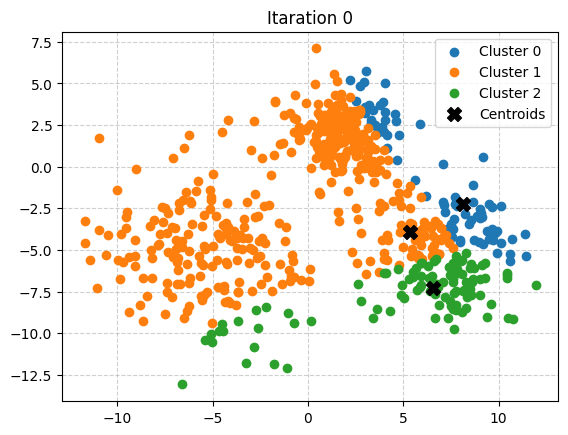

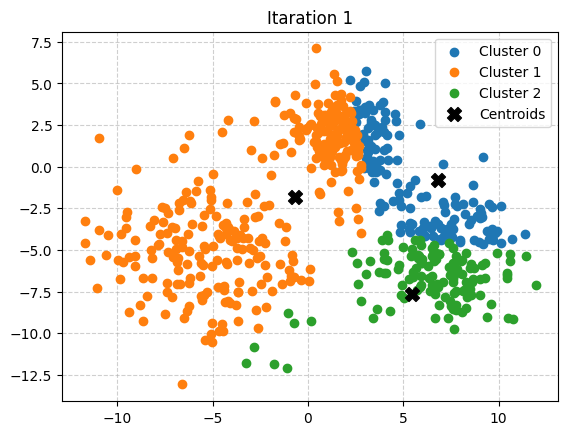

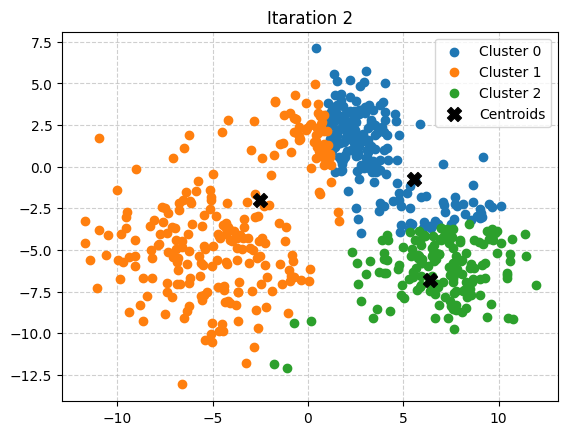

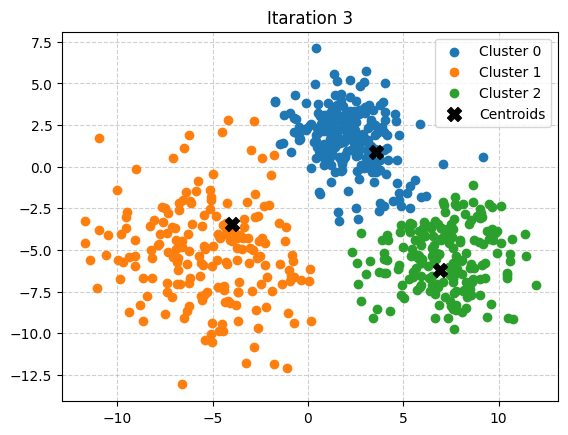

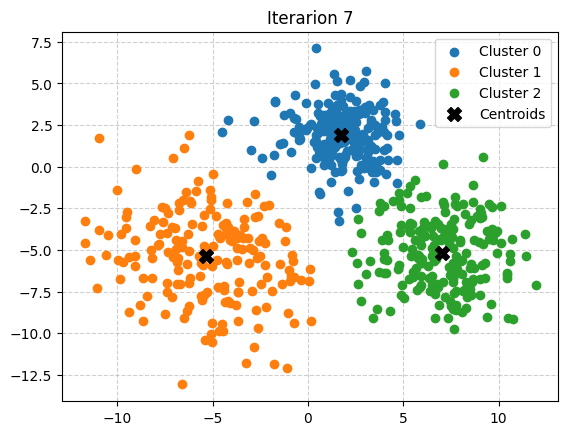

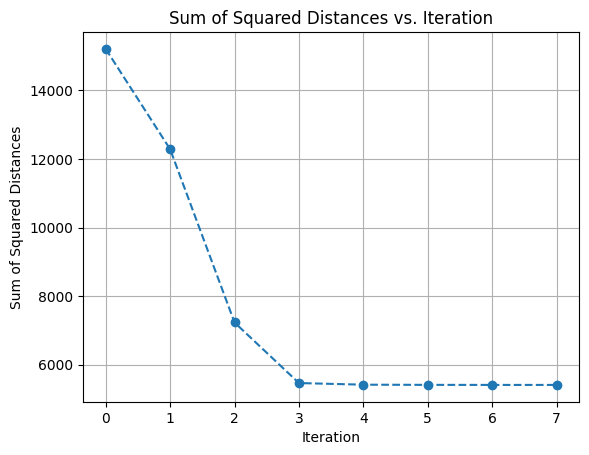

In [187]:
kmeans = Kmeans(3, random_state=SEED)

kmeans.fit(X, plot=[0, 1, 2, 3], plot_square=True)